# K562 Enhancer Classification with HyenaDNA
## A Different Architecture, the Same Biological Question

**Third notebook in the series — now using a state-space model instead of a transformer.**

---

### The Three-Notebook Journey

| Notebook | Question | Model | Architecture |
|----------|---------|-------|-------------|
| **1. Regression** | *How active* is this enhancer? | Nucleotide Transformer | Transformer (encoder) |
| **2. Classification** | *Is this* an enhancer? | Nucleotide Transformer | Transformer (encoder) |
| **3. This notebook** | *Is this* an enhancer? | **HyenaDNA** | **State-space model** |

### Why a third notebook?

The first two notebooks used the same model family (Nucleotide Transformer, a BERT-style
transformer). But the lecture says:

> *"This is not a ranking. It is a menu: match model to question."*

Different architectures encode different **inductive biases**. By solving the same
classification task with HyenaDNA, we can directly compare:
- **Transformer** (global attention, quadratic in sequence length) vs
- **State-space model** (implicit long convolutions, subquadratic scaling)

Same data. Same splits. Same metrics. Different model. This is how you do controlled
model comparison in practice.


## What is HyenaDNA?

### Architecture: State-Space Model (NOT a Transformer)

HyenaDNA (Nguyen et al., 2023) replaces the self-attention mechanism with the
**Hyena operator** — a subquadratic alternative based on implicit long convolutions.

| Feature | Nucleotide Transformer | HyenaDNA |
|---------|:---:|:---:|
| **Architecture** | Transformer (attention) | State-space model (Hyena operator) |
| **Attention** | Quadratic O(n²) | Subquadratic O(n log n) |
| **Tokenization** | Learned BPE-like tokens | **Character-level** (A, C, G, T, N) |
| **Context length** | ~1k tokens (~6kb DNA) | **Up to 1M bp** |
| **Pretraining** | Masked language model | **Next nucleotide prediction** (autoregressive) |
| **Pooling** | [CLS] token | **Mean pooling** (recommended) |
| **Parameters** | 500M | **14.2M** (medium) |

### Key insight: Character-level tokenization

HyenaDNA tokenizes each nucleotide individually. This means:
- A 1,000 bp sequence = 1,000 tokens (vs ~170 tokens with NT's learned tokenizer)
- **No information loss** from tokenization — every single base is preserved
- The model sees the raw sequence, not compressed sub-sequences
- But: more tokens per sequence = more compute per sequence

### Why mean pooling?

HyenaDNA is a **causal** (decoder-only) model pretrained with next-token prediction.
Unlike BERT-style models, it has no special [CLS] token trained for aggregation.
Research shows **mean pooling** outperforms last-token pooling by ~8.7% AUC on
classification tasks.

> *Lecture: "Architecture → Use Case Mapping: Decoder-only — generation and*
> *likelihood estimation, good for long-range dependencies"*


## Learning Objectives

Building on the previous two notebooks, you will:

1. **Load and use a state-space model** (HyenaDNA) for genomic classification
2. **Compare architectures** — transformer vs SSM on the same task and data
3. **Understand character-level tokenization** vs learned tokenization
4. **Analyze trade-offs** — model size, context length, and performance


In [1]:
# === INSTALLATION ===
#!apt-get update -qq && apt-get install -y -qq bedtools samtools wget > /dev/null 2>&1
#!pip install -q torch transformers pyBigWig pandas numpy scikit-learn tqdm matplotlib seaborn captum pyfaidx einops

# Download data (skip if already present from previous notebooks)
import os
if not os.path.exists('../../data/K562_H3K27ac.bigWig'):
    !wget -qO ../../data/K562_H3K27ac.bigWig "https://www.encodeproject.org/files/ENCFF465GBD/@@download/ENCFF465GBD.bigWig"
if not os.path.exists('../../data/K562_peaks.bed'):
    !wget -qO ../../data/K562_peaks.bed.gz "https://www.encodeproject.org/files/ENCFF038DDS/@@download/ENCFF038DDS.bed.gz" && gunzip -f ../../data/K562_peaks.bed.gz
if not os.path.exists('../../data/hg38.fa'):
    !wget -qO ../../data/hg38.fa.gz "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz" && gunzip -f ../../data/hg38.fa.gz && samtools faidx ../../data/hg38.fa
print('Data files ready.')


Data files ready.


In [11]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pyBigWig
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, accuracy_score, confusion_matrix,
                             roc_curve, precision_recall_curve)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from captum.attr import IntegratedGradients
from pyfaidx import Fasta
import pyBigWig
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from captum.attr import IntegratedGradients
from pyfaidx import Fasta
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================
QUICK_MODE = False

# HyenaDNA model — medium with 160k context length
# 14.2M params, 8 layers, d_model=256
# Supports up to 160,000 bp (our 1kb sequences are well within range)
HYENA_MODEL = "LongSafari/hyenadna-medium-160k-seqlen-hf"
HYENA_MAX_LENGTH = 1026    # 1000bp + special tokens, rounded up

if QUICK_MODE:
    MAX_PER_SPLIT = {'train': 5000, 'val': 1000, 'test': 2000}
    NUM_EPOCHS = 5
    BATCH_SIZE = 32
    print("QUICK_MODE: using data subset")
else:
    MAX_PER_SPLIT = {'train': None, 'val': None, 'test': None}
    NUM_EPOCHS = 10
    BATCH_SIZE = 32
    print("FULL MODE: using complete dataset")

NUM_UNFREEZE_LAYERS = 2
PATIENCE = 3

# Output directory
OUTPUT_DIR = Path('../../output/k562_hyenadna_classification')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

## Step 0 — The Same Biological Question

> This is identical to the classification notebook. We ask:
> **Given a 1 kb DNA sequence, is it an active enhancer (H3K27ac peak) in K562?**

The only thing that changes is **the model**. Data, splits, and evaluation are the same,
enabling a fair architectural comparison.


In [13]:
!ls ../../data

download_gencode_files.sh			  gencode.v44.transcripts.fa.gz
download_k562_h3k27ac_files.sh			  hg38.fa
gencode.v44.100_protein_coding_and_100_lncRNA.fa  hg38.fa.fai
gencode.v44.annotation.gtf.gz			  K562_H3K27ac.bigWig
gencode.v44.transcripts.fa			  K562_peaks.bed


In [14]:
bw = pyBigWig.open('../../data/K562_H3K27ac.bigWig')

In [16]:
# ============================================================
# Steps 0+3: Load data, generate negatives, split by chromosome
# (Identical to the classification notebook)
# ============================================================

bw = pyBigWig.open('../../data/K562_H3K27ac.bigWig')
peaks = pd.read_csv('../../data/K562_peaks.bed', sep='\t', header=None, comment='#')
peaks.columns = ['chrom','start','end','name','score','strand','signal','pval','qval','peak']
peaks['summit'] = peaks['start'] + peaks['peak']
peaks['win_start'] = peaks['summit'] - 500
peaks['win_end'] = peaks['summit'] + 500

valid_chroms = ['chr' + str(i) for i in range(1, 23)] + ['chrX']
peaks = peaks[peaks.chrom.isin(valid_chroms)]
peaks = peaks[peaks.win_start >= 0]

genome = Fasta('../../data/hg38.fa')
def get_seq(chrom, start, end):
    try: return str(genome[chrom][start:end]).upper()
    except: return None

peaks['sequence'] = peaks.apply(lambda r: get_seq(r.chrom, r.win_start, r.win_end), axis=1)
peaks = peaks.dropna(subset=['sequence'])
peaks = peaks[peaks.sequence.apply(lambda s: s.count('N')/len(s) < 0.1)].reset_index(drop=True)
print(f'Positive examples: {len(peaks):,}')

# --- Generate negatives (same code as classification notebook) ---
chrom_sizes = {}
with open('../../data/hg38.fa.fai') as f:
    for line in f:
        parts = line.strip().split('\t')
        if parts[0] in valid_chroms:
            chrom_sizes[parts[0]] = int(parts[1])

BIN_SIZE = 500
occupied_bins = set()
for _, row in peaks.iterrows():
    for b in range(row.win_start // BIN_SIZE, row.win_end // BIN_SIZE + 1):
        occupied_bins.add((row.chrom, b))

def overlaps_peak(chrom, start, end):
    for b in range(start // BIN_SIZE, end // BIN_SIZE + 1):
        if (chrom, b) in occupied_bins: return True
    return False

np.random.seed(42)
negatives = []
for chrom, n_pos in sorted(peaks.chrom.value_counts().to_dict().items()):
    size = chrom_sizes.get(chrom, 0)
    if size < 2000: continue
    found, attempts = 0, 0
    while found < n_pos and attempts < n_pos * 30:
        center = np.random.randint(500, size - 500)
        s, e = center - 500, center + 500
        if not overlaps_peak(chrom, s, e):
            negatives.append({'chrom': chrom, 'win_start': s, 'win_end': e})
            found += 1
        attempts += 1

neg_df = pd.DataFrame(negatives)
neg_df['sequence'] = neg_df.apply(lambda r: get_seq(r.chrom, r.win_start, r.win_end), axis=1)
neg_df = neg_df.dropna(subset=['sequence'])
neg_df = neg_df[neg_df.sequence.apply(lambda s: s.count('N')/len(s) < 0.1)]
neg_df['label'] = 0

pos_df = peaks[['chrom','win_start','win_end','sequence']].copy()
pos_df['label'] = 1
all_data = pd.concat([pos_df, neg_df], ignore_index=True)

# Chromosome-aware splits (same as lecture)
train_chroms = ['chr' + str(i) for i in range(1, 17)]
val_chroms   = ['chr17', 'chr18']
test_chroms  = ['chr' + str(i) for i in range(19, 23)] + ['chrX']

train_df = all_data[all_data.chrom.isin(train_chroms)].copy()
val_df   = all_data[all_data.chrom.isin(val_chroms)].copy()
test_df  = all_data[all_data.chrom.isin(test_chroms)].copy()

print(f'Full splits:')
for nm, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'  {nm}: {len(df):,} (pos={int(df.label.sum()):,}, neg={int((1-df.label).sum()):,})')

if QUICK_MODE:
    for name, max_n in MAX_PER_SPLIT.items():
        if max_n is None: continue
        df = {'train': train_df, 'val': val_df, 'test': test_df}[name]
        if len(df) > max_n:
            n_each = max_n // 2
            pos_s = df[df.label==1].sample(n=min(n_each, int(df.label.sum())), random_state=42)
            neg_s = df[df.label==0].sample(n=min(n_each, int((1-df.label).sum())), random_state=42)
            sampled = pd.concat([pos_s, neg_s]).sample(frac=1, random_state=42)
            if name == 'train': train_df = sampled
            elif name == 'val': val_df = sampled
            else: test_df = sampled
    print(f'After QUICK_MODE:')
    for nm, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        print(f'  {nm}: {len(df):,} (balance={df.label.mean():.1%})')


Positive examples: 52,315
Full splits:
  Train: 78,460 (pos=40,075, neg=38,385)
  Val: 7,460 (pos=3,738, neg=3,722)
  Test: 16,580 (pos=8,502, neg=8,078)


## Step 1 — Model Selection: HyenaDNA

> *Lecture: "Match model to question."*

### Why try HyenaDNA?

| Consideration | Nucleotide Transformer (prev. notebook) | HyenaDNA (this notebook) |
|:---:|:---:|:---:|
| **Pre-training** | Masked language model | Next-nucleotide prediction |
| **Tokenization** | Learned (~170 tokens/kb) | Character-level (~1000 tokens/kb) |
| **Parameters** | 500M | **14.2M (35x smaller!)** |
| **Max context** | ~6 kb | **160,000 bp** |
| **Scaling** | O(n²) attention | O(n log n) Hyena operator |

### What we learn from this comparison

- Does a **35x smaller** model with a different architecture match the transformer?
- Does **character-level tokenization** (no information loss) help or hurt?
- Is the SSM's **subquadratic scaling** relevant for our 1 kb sequences?

> For 1 kb sequences, both models are comfortable. The scaling advantage of HyenaDNA
> becomes decisive for longer sequences (>10 kb), which you might explore as an extension.


In [21]:
# ============================================================
# Step 1: Load HyenaDNA and inspect its architecture
# ============================================================
# IMPORTANT: trust_remote_code=True is REQUIRED for HyenaDNA
# This downloads custom model code from the HuggingFace repo.

print(f'Loading HyenaDNA model: {HYENA_MODEL}')
print('(This downloads ~60MB of model weights on first run)')

hyena_tokenizer = AutoTokenizer.from_pretrained(
    HYENA_MODEL, trust_remote_code=True
)

# Let's see how HyenaDNA tokenizes DNA — character by character!
example = "ATCGATCG"
tokens = hyena_tokenizer(example)
print(f'\nTokenization example:')
print(f'  Sequence: {example}')
print(f'  Token IDs: {tokens["input_ids"]}')
print(f'  Each nucleotide becomes one token — no information loss!')
print(f'\nVocabulary size: {hyena_tokenizer.vocab_size}')
print(f'  (Just A, C, G, T, N + special tokens — much smaller than NT\'s {4107:,})')

# Verify: 1kb sequence token count
test_enc = hyena_tokenizer("A" * 1000, truncation=True, max_length=HYENA_MAX_LENGTH)
print(f'\n1000bp sequence -> {len(test_enc["input_ids"])} tokens')


Loading HyenaDNA model: LongSafari/hyenadna-medium-160k-seqlen-hf
(This downloads ~60MB of model weights on first run)

Tokenization example:
  Sequence: ATCGATCG
  Token IDs: [7, 10, 8, 9, 7, 10, 8, 9, 1]
  Each nucleotide becomes one token — no information loss!

Vocabulary size: 12
  (Just A, C, G, T, N + special tokens — much smaller than NT's 4,107)

1000bp sequence -> 1001 tokens


In [22]:
# ============================================================
# Step 1: Define HyenaDNA classifier
# ============================================================
# Key differences from the NT classifier:
#   1. No attention_mask needed (SSMs process sequentially)
#   2. Mean pooling instead of [CLS] token
#   3. Output is a tuple; [0] = hidden states

class HyenaDNAClassifier(nn.Module):
    """HyenaDNA backbone + classification head.

    Uses mean pooling over sequence positions (not [CLS] token).
    Research shows mean pooling outperforms last-token pooling
    by ~8.7% AUC for HyenaDNA classification tasks.
    """
    def __init__(self, model_name, freeze_backbone=False):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(
            model_name, trust_remote_code=True
        )
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        d_model = self.backbone.config.d_model  # 256 for medium
        self.head = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, input_ids):
        # HyenaDNA returns a tuple; [0] = hidden states (batch, seq_len, d_model)
        hidden = self.backbone(input_ids)[0]
        # Mean pooling over the sequence dimension
        # (No [CLS] token — HyenaDNA is a causal model)
        pooled = hidden.mean(dim=1)  # (batch, d_model)
        return self.head(pooled).squeeze(-1)  # raw logit

# Inspect the model structure (educational)
_temp = AutoModel.from_pretrained(HYENA_MODEL, trust_remote_code=True)
print(f'HyenaDNA-medium architecture:')
print(f'  d_model: {_temp.config.d_model}')
print(f'  n_layer: {_temp.config.n_layer}')
total_p = sum(p.numel() for p in _temp.parameters())
print(f'  Total parameters: {total_p:,}')
print(f'  (Compare: NT-500M has {480_602_338:,} — HyenaDNA is {480_602_338//total_p}x smaller)')
del _temp  # free memory


HyenaDNA-medium architecture:
  d_model: 256
  n_layer: 8
  Total parameters: 6,550,528
  (Compare: NT-500M has 480,602,338 — HyenaDNA is 73x smaller)


In [23]:
# ============================================================
# Step 1: CNN Baseline (same as classification notebook)
# ============================================================

def one_hot_encode(seq, length=1000):
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    encoded = np.zeros((4, length), dtype=np.float32)
    for i, base in enumerate(seq[:length]):
        if base in mapping:
            encoded[mapping[base], i] = 1.0
    return encoded

class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(4, 64, kernel_size=15, padding=7),
            nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.ReLU(), nn.BatchNorm1d(128), nn.MaxPool1d(4),
            nn.Conv1d(128, 64, kernel_size=5, padding=2),
            nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.head(self.conv(x).squeeze(-1)).squeeze(-1)


## Steps 4–5 — Tokenization: Character-Level vs Learned

This is a key architectural difference worth understanding.

### How each model sees the same 1 kb sequence

| Model | Tokenizer | Token count for 1 kb | What each token represents |
|-------|-----------|:---:|---|
| **Nucleotide Transformer** | Learned (BPE-like) | ~170 | Multi-base sub-sequences |
| **HyenaDNA** | Character-level | ~1,000 | **Individual nucleotides** |
| **CNN** | One-hot encoding | 1,000 × 4 | One-hot vectors per base |

### Implications

- **HyenaDNA sees 6x more tokens** per sequence than NT — more positions to attend to,
  but each position carries less context
- **No tokenization artifacts** — with character-level tokens, every SNV is visible.
  With learned tokens, a mutation might or might not change the token boundary
- **Longer sequences are more natural** for HyenaDNA — its subquadratic scaling means
  you could input 100 kb windows without the quadratic memory blow-up of transformers

> *Lecture: "Wrong tokenization can lead to silent failure:*
> *too coarse → miss single-nucleotide variants"*
> Character-level tokenization avoids this risk entirely.


In [24]:
# ============================================================
# Steps 4-5: Dataset classes
# ============================================================

class HyenaDataset(Dataset):
    """Dataset for HyenaDNA: character-level tokenized input."""
    def __init__(self, df):
        self.seqs = df.sequence.values
        self.labels = df.label.values.astype(np.float32)
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        enc = hyena_tokenizer(
            self.seqs[idx], return_tensors='pt',
            truncation=True, padding='max_length',
            max_length=HYENA_MAX_LENGTH,
        )
        return {
            'input_ids': enc.input_ids.squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32),
        }

class CNNDataset(Dataset):
    def __init__(self, df, seq_len=1000):
        self.seqs = df.sequence.values
        self.labels = df.label.values.astype(np.float32)
        self.seq_len = seq_len
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        return {
            'sequence': torch.tensor(one_hot_encode(self.seqs[idx], self.seq_len)),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32),
        }

# Create DataLoaders
train_loader_hyena = DataLoader(HyenaDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader_hyena   = DataLoader(HyenaDataset(val_df),   batch_size=BATCH_SIZE)
test_loader_hyena  = DataLoader(HyenaDataset(test_df),  batch_size=BATCH_SIZE)

train_loader_cnn = DataLoader(CNNDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader_cnn   = DataLoader(CNNDataset(val_df),   batch_size=BATCH_SIZE)
test_loader_cnn  = DataLoader(CNNDataset(test_df),  batch_size=BATCH_SIZE)

print(f'Hyena — Train: {len(train_loader_hyena)} batches | Val: {len(val_loader_hyena)} | Test: {len(test_loader_hyena)}')
print(f'CNN   — Train: {len(train_loader_cnn)} batches | Val: {len(val_loader_cnn)} | Test: {len(test_loader_cnn)}')


Hyena — Train: 2452 batches | Val: 234 | Test: 519
CNN   — Train: 2452 batches | Val: 234 | Test: 519


## Step 6 — Experimental Setup

Same as the classification notebook: **BCEWithLogitsLoss**, early stopping on
**validation AUROC**, metrics = AUROC, AUPRC, F1, accuracy.

### One difference in the training code

HyenaDNA's forward pass only takes `input_ids` — no `attention_mask`.
This is because state-space models process sequences as continuous signals,
not as discrete attention patterns. The model handles padding internally.


In [25]:
# ============================================================
# Step 6: Training and evaluation utilities
# ============================================================

def train_one_epoch(model, loader, optimizer, loss_fn, model_type='hyena'):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc='Training', leave=False):
        optimizer.zero_grad()
        labels = batch['labels'].to(device)
        if model_type == 'hyena':
            logits = model(batch['input_ids'].to(device))
        else:  # cnn
            logits = model(batch['sequence'].to(device))
        loss = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, model_type='hyena'):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            if model_type == 'hyena':
                logits = model(batch['input_ids'].to(device))
            else:
                logits = model(batch['sequence'].to(device))
            all_logits.append(logits.cpu())
            all_labels.append(batch['labels'])
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {
        'auroc': float(roc_auc_score(labels, probs)),
        'auprc': float(average_precision_score(labels, probs)),
        'f1':    float(f1_score(labels, preds)),
        'accuracy': float(accuracy_score(labels, preds)),
    }

def get_predictions(model, loader, model_type='hyena'):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            if model_type == 'hyena':
                logits = model(batch['input_ids'].to(device))
            else:
                logits = model(batch['sequence'].to(device))
            all_logits.append(logits.cpu())
            all_labels.append(batch['labels'])
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    return 1 / (1 + np.exp(-logits)), labels

def train_model(model, train_ldr, val_ldr, optimizer, loss_fn,
                model_type='hyena', num_epochs=NUM_EPOCHS, patience=PATIENCE,
                save_path='best.pt'):
    best_auroc = -1
    patience_ctr = 0
    history = {'train_loss': [], 'val_auroc': [], 'val_auprc': []}
    for epoch in range(num_epochs):
        loss = train_one_epoch(model, train_ldr, optimizer, loss_fn, model_type)
        val = evaluate(model, val_ldr, model_type)
        history['train_loss'].append(loss)
        history['val_auroc'].append(val['auroc'])
        history['val_auprc'].append(val['auprc'])
        print(f'  Epoch {epoch+1}/{num_epochs} — Loss: {loss:.4f} | '
              f'Val AUROC: {val["auroc"]:.4f} | Val AUPRC: {val["auprc"]:.4f}')
        if val['auroc'] > best_auroc:
            best_auroc = val['auroc']
            torch.save(model.state_dict(), save_path)
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return model, history


## Step 7 — Fine-Tuning

### Stage 1: Frozen Backbone

> *Lecture: "Freeze backbone, train prediction head → diagnostic baseline"*

With only 14.2M backbone parameters (vs NT's 500M), freezing is even more
important — we want to verify the pre-trained representations are useful
before investing in unfreezing.


In [ ]:
# ============================================================
# Step 7, Stage 1: Frozen backbone
# ============================================================

print('=' * 60)
print('STAGE 1: Frozen HyenaDNA Backbone')
print('=' * 60)

hyena_model = HyenaDNAClassifier(HYENA_MODEL, freeze_backbone=True).to(device)
trainable = sum(p.numel() for p in hyena_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in hyena_model.parameters())
print(f'Trainable: {trainable:,} / {total_params:,} ({100*trainable/total_params:.2f}%)')

optimizer_s1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, hyena_model.parameters()),
    lr=1e-3, weight_decay=0.01
)
loss_fn = nn.BCEWithLogitsLoss()

hyena_model, history_s1 = train_model(
    hyena_model, train_loader_hyena, val_loader_hyena, optimizer_s1, loss_fn,
    model_type='hyena', save_path=OUTPUT_DIR / 'best_hyena_frozen.pt'
)

frozen_test = evaluate(hyena_model, test_loader_hyena, model_type='hyena')
print(f'\nStage 1 (Frozen) Test Results:')
for k, v in frozen_test.items(): print(f'  {k}: {v:.4f}')

### Stage 2: Partial Unfreeze

HyenaDNA-medium has **8 Hyena layers**. We unfreeze the top 2 with a lower
learning rate, same strategy as the NT notebooks.

> *Lecture: "Unfreeze top N layers (e.g., 2–4), train with low LR on backbone"*


In [ ]:
# ============================================================
# Step 7, Stage 2: Unfreeze top layers of HyenaDNA
# ============================================================

print('=' * 60)
print(f'STAGE 2: Unfreezing Top {NUM_UNFREEZE_LAYERS} Layers')
print('=' * 60)

hyena_model.load_state_dict(
    torch.load(OUTPUT_DIR / 'best_hyena_frozen.pt', map_location=device, weights_only=True)
)

# Discover the layer structure (educational — SSMs have different internals)
hyena_layers = None
for name, module in hyena_model.backbone.named_modules():
    if isinstance(module, nn.ModuleList) and len(list(module)) > 2:
        hyena_layers = list(module)
        print(f'Found {len(hyena_layers)} layers at: backbone.{name}')
        break

if hyena_layers is None:
    print('Could not auto-detect layers — unfreezing all backbone parameters')
    for p in hyena_model.backbone.parameters():
        p.requires_grad = True
    unfrozen_params = list(hyena_model.backbone.parameters())
else:
    print(f'Unfreezing top {NUM_UNFREEZE_LAYERS} of {len(hyena_layers)} layers')
    unfrozen_params = []
    for layer in hyena_layers[-NUM_UNFREEZE_LAYERS:]:
        for p in layer.parameters():
            p.requires_grad = True
        unfrozen_params.extend(layer.parameters())

trainable = sum(p.numel() for p in hyena_model.parameters() if p.requires_grad)
print(f'Trainable: {trainable:,} / {total_params:,} ({100*trainable/total_params:.2f}%)')

# Differential learning rates
optimizer_s2 = torch.optim.AdamW([
    {'params': hyena_model.head.parameters(), 'lr': 1e-3},
    {'params': unfrozen_params, 'lr': 1e-5},
], weight_decay=0.01)

hyena_model, history_s2 = train_model(
    hyena_model, train_loader_hyena, val_loader_hyena, optimizer_s2, loss_fn,
    model_type='hyena', save_path=OUTPUT_DIR / 'best_hyena_partial.pt'
)

partial_test = evaluate(hyena_model, test_loader_hyena, model_type='hyena')
print(f'\nStage 2 (Partial FT) Test Results:')
for k, v in partial_test.items(): print(f'  {k}: {v:.4f}')

### CNN Baseline

Same CNN as the previous notebooks — our constant reference point across all experiments.


In [ ]:
# ============================================================
# Step 7: CNN Baseline
# ============================================================

print('=' * 60)
print('CNN BASELINE')
print('=' * 60)

cnn_model = CNNClassifier().to(device)
print(f'CNN parameters: {sum(p.numel() for p in cnn_model.parameters()):,}')

optimizer_cnn = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=0.01)
cnn_model, history_cnn = train_model(
    cnn_model, train_loader_cnn, val_loader_cnn, optimizer_cnn, loss_fn,
    model_type='cnn', save_path=OUTPUT_DIR / 'best_hyena_cnn.pt'
)

cnn_test = evaluate(cnn_model, test_loader_cnn, model_type='cnn')
print(f'\nCNN Baseline Test Results:')
for k, v in cnn_test.items(): print(f'  {k}: {v:.4f}')

## Step 8 — Evaluation & Interpretation

> *Lecture: "Beyond scalar performance... Attribution maps, motif recovery,*
> *per-chromosome generalization."*


In [13]:
# ============================================================
# Step 8: Model comparison
# ============================================================

results_table = pd.DataFrame({
    'HyenaDNA Frozen': frozen_test,
    'HyenaDNA Partial FT': partial_test,
    'CNN Baseline': cnn_test,
}).T

print('=' * 60)
print('MODEL COMPARISON (Test Set)')
print('=' * 60)
print(results_table.to_string(float_format='{:.4f}'.format))


MODEL COMPARISON (Test Set)
                     auroc  auprc     f1  accuracy
HyenaDNA Frozen     0.7945 0.7966 0.7320    0.7140
HyenaDNA Partial FT 0.8270 0.8308 0.7523    0.7350
CNN Baseline        0.8205 0.8272 0.6820    0.7235


In [ ]:
# ============================================================
# Step 8: ROC and Precision-Recall curves
# ============================================================

hyena_frozen = HyenaDNAClassifier(HYENA_MODEL, freeze_backbone=True).to(device)
hyena_frozen.load_state_dict(
    torch.load(OUTPUT_DIR / 'best_hyena_frozen.pt', map_location=device, weights_only=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_for_curves = [
    ('HyenaDNA Frozen',     hyena_frozen, test_loader_hyena, 'hyena'),
    ('HyenaDNA Partial FT', hyena_model,  test_loader_hyena, 'hyena'),
    ('CNN Baseline',         cnn_model,    test_loader_cnn,   'cnn'),
]
colors = ['#9C27B0', '#4CAF50', '#FF9800']

for (name, mdl, ldr, mtype), color in zip(models_for_curves, colors):
    probs, labels = get_predictions(mdl, ldr, mtype)
    fpr, tpr, _ = roc_curve(labels, probs)
    auroc = roc_auc_score(labels, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUROC={auroc:.3f})')
    prec, rec, _ = precision_recall_curve(labels, probs)
    auprc = average_precision_score(labels, probs)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{name} (AUPRC={auprc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(loc='lower right')

baseline = test_df.label.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', alpha=0.3, label=f'Random ({baseline:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(loc='lower left')

plt.suptitle('HyenaDNA Classification Performance', fontsize=14)
plt.tight_layout(); plt.show()

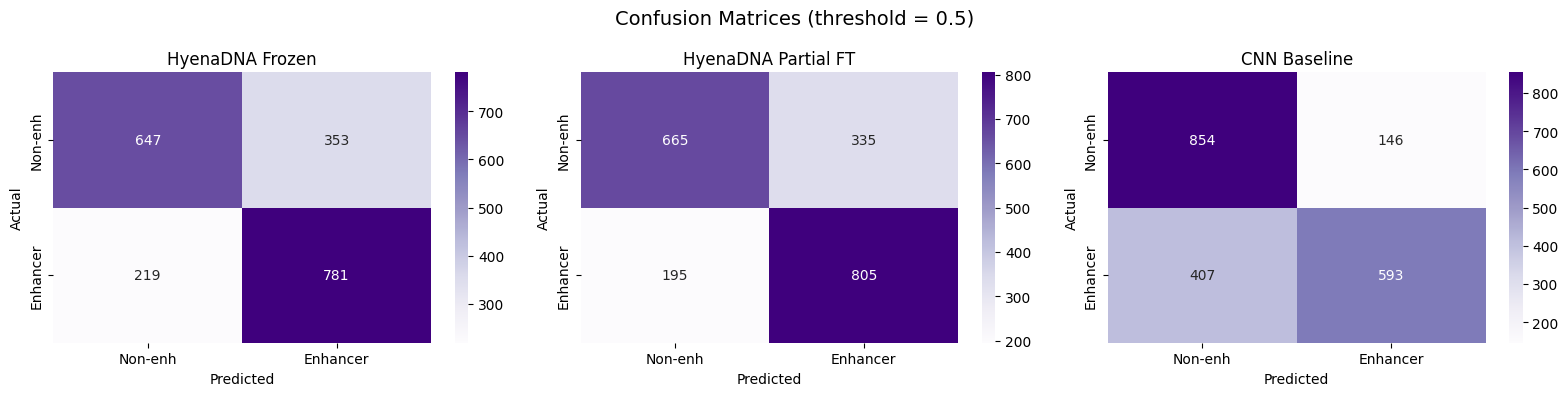

In [15]:
# ============================================================
# Step 8: Confusion matrices
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, mdl, ldr, mtype) in zip(axes, models_for_curves):
    probs, labels = get_predictions(mdl, ldr, mtype)
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=['Non-enh', 'Enhancer'],
                yticklabels=['Non-enh', 'Enhancer'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(name)
plt.suptitle('Confusion Matrices (threshold = 0.5)', fontsize=14)
plt.tight_layout(); plt.show()


Per-Chromosome AUROC (HyenaDNA Partial FT)
--------------------------------------------------
  chr19 (n=820): AUROC=0.862, F1=0.782
  chr20 (n=360): AUROC=0.801, F1=0.715
  chr21 (n=115): AUROC=0.775, F1=0.667
  chr22 (n=267): AUROC=0.805, F1=0.777
  chrX (n=438): AUROC=0.837, F1=0.721


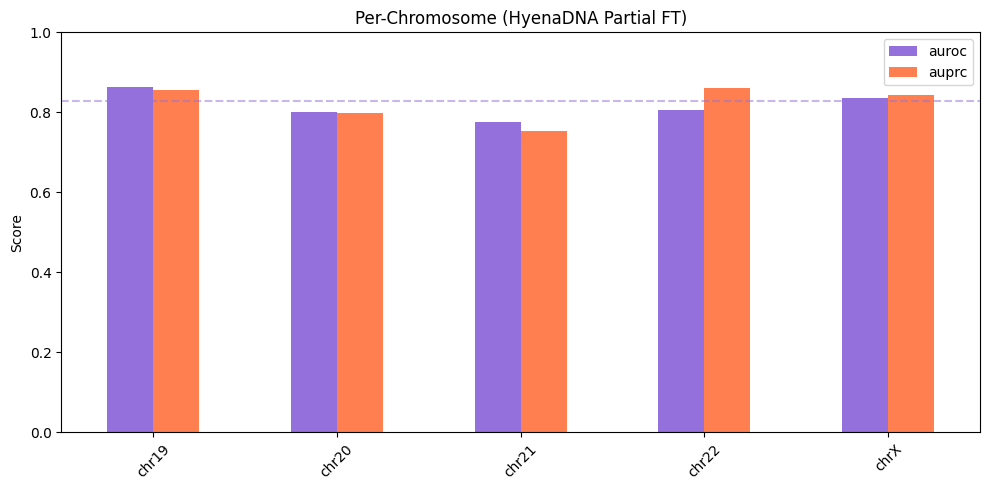

In [16]:
# ============================================================
# Step 8: Per-chromosome AUROC
# ============================================================

print('Per-Chromosome AUROC (HyenaDNA Partial FT)')
print('-' * 50)

chrom_results = {}
for chrom in test_chroms:
    subset = test_df[test_df.chrom == chrom]
    if len(subset) < 20 or subset.label.nunique() < 2: continue
    ldr = DataLoader(HyenaDataset(subset), batch_size=BATCH_SIZE)
    metrics = evaluate(hyena_model, ldr, model_type='hyena')
    chrom_results[chrom] = metrics
    print(f'  {chrom} (n={len(subset):,}): AUROC={metrics["auroc"]:.3f}, F1={metrics["f1"]:.3f}')

if chrom_results:
    chrom_df = pd.DataFrame(chrom_results).T
    fig, ax = plt.subplots(figsize=(10, 5))
    chrom_df[['auroc', 'auprc']].plot.bar(ax=ax, color=['mediumpurple', 'coral'])
    ax.axhline(y=partial_test['auroc'], color='mediumpurple', linestyle='--', alpha=0.5)
    ax.set_ylabel('Score'); ax.set_title('Per-Chromosome (HyenaDNA Partial FT)')
    ax.set_ylim(0, 1); plt.xticks(rotation=45); plt.legend()
    plt.tight_layout(); plt.show()


### Saliency Analysis

Same approach as the classification notebook: Integrated Gradients on the CNN baseline.
The CNN gives us a clean, model-agnostic view of which sequence positions matter,
independent of the foundation model used.


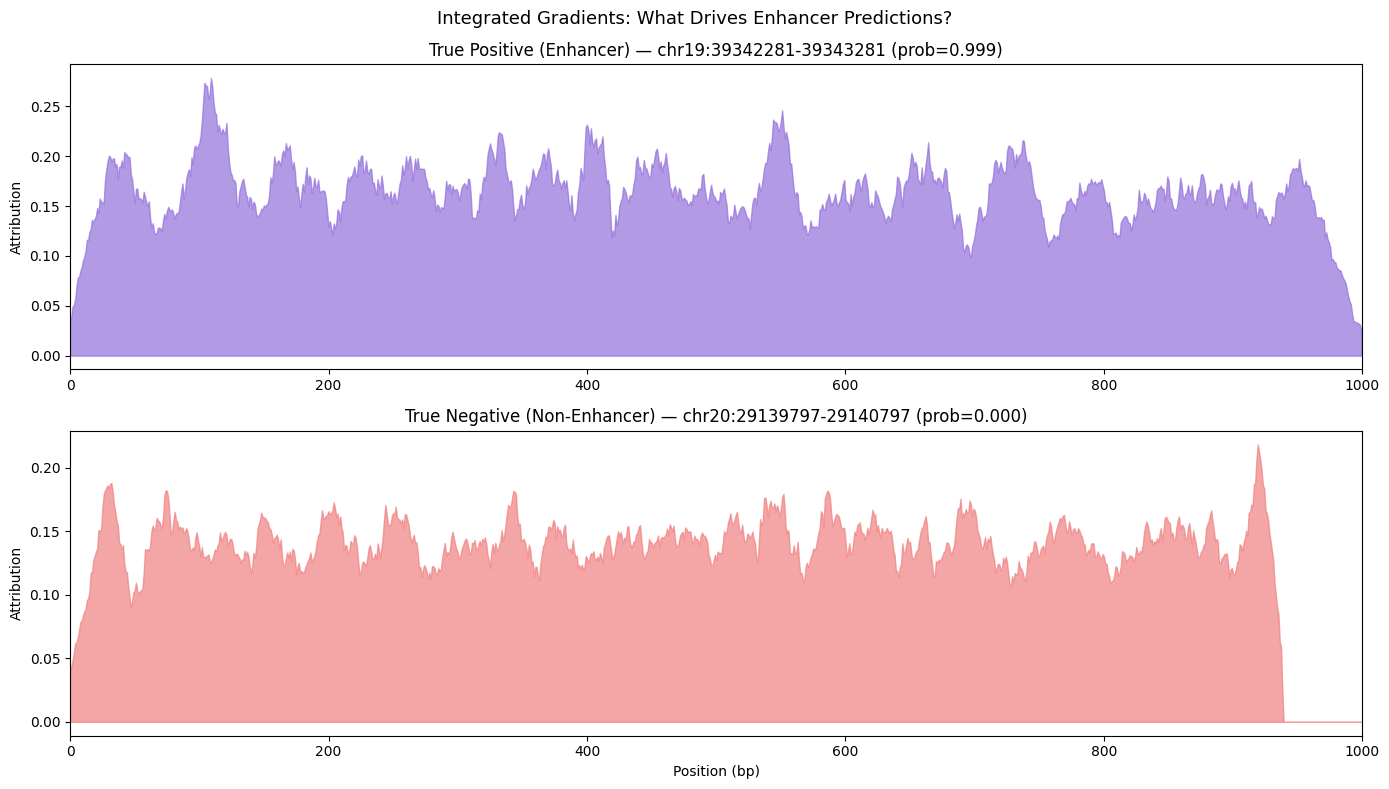

In [17]:
# ============================================================
# Step 8: Saliency (Integrated Gradients on CNN)
# ============================================================

cnn_model.eval()
probs_cnn, labels_cnn = get_predictions(cnn_model, test_loader_cnn, 'cnn')
preds_cnn = (probs_cnn >= 0.5).astype(int)

tp_indices = np.where((labels_cnn == 1) & (preds_cnn == 1))[0]
tn_indices = np.where((labels_cnn == 0) & (preds_cnn == 0))[0]

if len(tp_indices) > 0 and len(tn_indices) > 0:
    tp_idx = tp_indices[probs_cnn[tp_indices].argmax()]
    tn_idx = tn_indices[probs_cnn[tn_indices].argmin()]
    ig = IntegratedGradients(cnn_model)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    for ax, idx, title, color in [
        (axes[0], tp_idx, 'True Positive (Enhancer)', 'mediumpurple'),
        (axes[1], tn_idx, 'True Negative (Non-Enhancer)', 'lightcoral'),
    ]:
        row = test_df.iloc[idx]
        enc = torch.tensor(one_hot_encode(row.sequence), dtype=torch.float32).unsqueeze(0).to(device)
        enc.requires_grad_(True)
        attrs = ig.attribute(enc, n_steps=50)
        importance = np.abs(attrs.squeeze().cpu().detach().numpy()).sum(axis=0)
        smoothed = np.convolve(importance, np.ones(20)/20, mode='same')
        ax.fill_between(range(len(smoothed)), smoothed, alpha=0.7, color=color)
        ax.set_title(f'{title} — {row.chrom}:{row.win_start}-{row.win_end} (prob={probs_cnn[idx]:.3f})')
        ax.set_ylabel('Attribution'); ax.set_xlim(0, len(smoothed))
    axes[1].set_xlabel('Position (bp)')
    plt.suptitle('Integrated Gradients: What Drives Enhancer Predictions?', fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print('Not enough correct predictions for saliency analysis')


### Training Curves

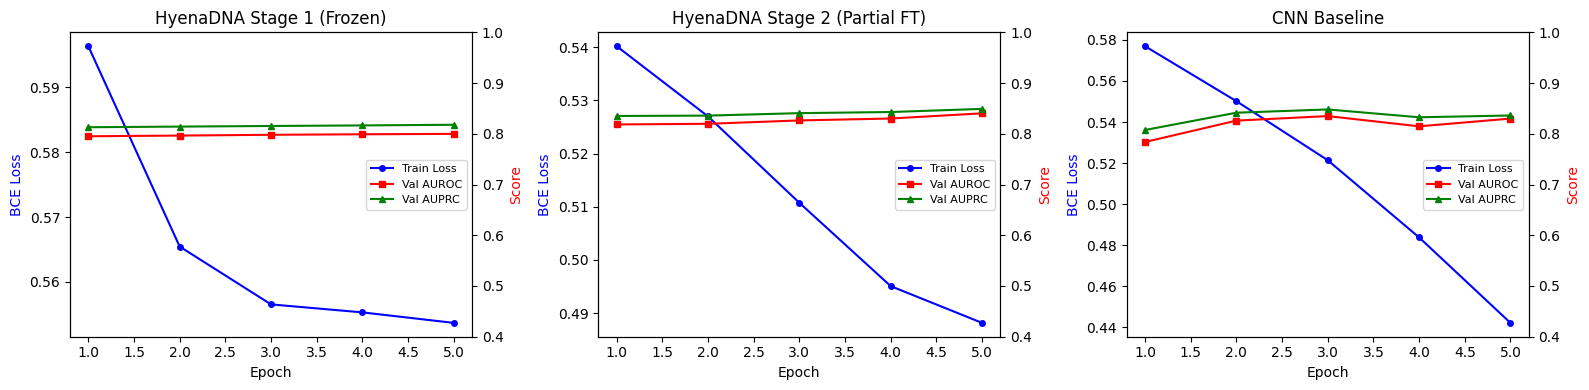

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (title, hist) in zip(axes, [
    ('HyenaDNA Stage 1 (Frozen)', history_s1),
    ('HyenaDNA Stage 2 (Partial FT)', history_s2),
    ('CNN Baseline', history_cnn),
]):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax2 = ax.twinx()
    ax.plot(epochs, hist['train_loss'], 'b-o', markersize=4, label='Train Loss')
    ax2.plot(epochs, hist['val_auroc'], 'r-s', markersize=4, label='Val AUROC')
    ax2.plot(epochs, hist['val_auprc'], 'g-^', markersize=4, label='Val AUPRC')
    ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss', color='b')
    ax2.set_ylabel('Score', color='r'); ax2.set_ylim(0.4, 1.0)
    ax.set_title(title)
    l1, lb1 = ax.get_legend_handles_labels()
    l2, lb2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, lb1+lb2, loc='center right', fontsize=8)
plt.tight_layout(); plt.show()


## Transformer vs State-Space Model — What Did We Learn?

### Architecture comparison on the same task

| Aspect | Nucleotide Transformer | HyenaDNA-medium |
|--------|:---:|:---:|
| **Architecture** | Transformer (attention) | SSM (Hyena operator) |
| **Parameters** | 500M | 14.2M |
| **Tokenization** | Learned (~170 tokens/kb) | Character-level (~1000 tokens/kb) |
| **Pretraining** | Masked LM | Next-nucleotide prediction |
| **Context window** | ~6 kb | 160 kb |
| **GPU memory** | High | Low |
| **Training speed** | Slower (large model) | Faster (small model) |

### Key takeaways

1. **Model size ≠ performance.** A 14M-parameter SSM can be competitive with a
   500M-parameter transformer on short-range tasks like 1 kb enhancer classification.

2. **Architecture matters less than data.** Both models benefit from the same careful
   data curation (chromosome splits, negative sampling, normalization).

3. **Character-level tokenization** preserves full sequence information but creates
   longer token sequences. For 1 kb, this is manageable. For 100 kb+, HyenaDNA's
   subquadratic scaling becomes essential.

4. **The CNN baseline remains a strong reference.** If a 100K-parameter CNN matches
   both foundation models, the pretrained representations may not be necessary for
   this specific task at this specific sequence length.

> *Lecture: "A systematic workflow plus reflective iteration beats trial-and-error*
> *hyperparameter fishing."* — The workflow is the same regardless of the model.

### When to choose which?

| Scenario | Recommended Model |
|----------|------------------|
| Short sequences (< 2 kb), need interpretability | **CNN** or **NT** |
| Short sequences, need best accuracy | **NT** (more parameters, richer pretrained features) |
| Long sequences (10–100+ kb) | **HyenaDNA** (subquadratic scaling) |
| Limited GPU memory | **HyenaDNA** (14M vs 500M params) |
| Variant effect prediction (single-base resolution) | **HyenaDNA** (character-level tokens) |


## Summary

### What We Learned

1. **State-space models** (HyenaDNA) offer a fundamentally different approach to
   genomic sequence modeling — subquadratic scaling + character-level tokenization
2. **The same workflow applies** regardless of architecture — the lecture's 8-step
   pipeline (question → model → data → tokenize → preprocess → train → evaluate → interpret)
   works identically
3. **Controlled comparison** (same data, splits, metrics) is the only way to fairly
   assess architectures — everything else held constant, only the model changes

### The Complete Notebook Series

| # | Notebook | Task | Model | Key Lesson |
|---|---------|------|-------|-----------|
| 1 | Regression | How active? | NT-500M | The canonical GFM workflow |
| 2 | Classification | Enhancer or not? | NT-500M | Negative sampling, classification metrics |
| 3 | **This notebook** | Enhancer or not? | **HyenaDNA** | **Architecture comparison, tokenization trade-offs** |

### Extensions

- **Long-range tasks** — use 10–100 kb windows where HyenaDNA's scaling advantage shines
- **HyenaDNA-large-1M** — 54.6M params, 1M bp context (needs A100 GPU)
- **Ensemble** — combine NT and HyenaDNA predictions
- **Multi-task** — predict multiple histone marks simultaneously
